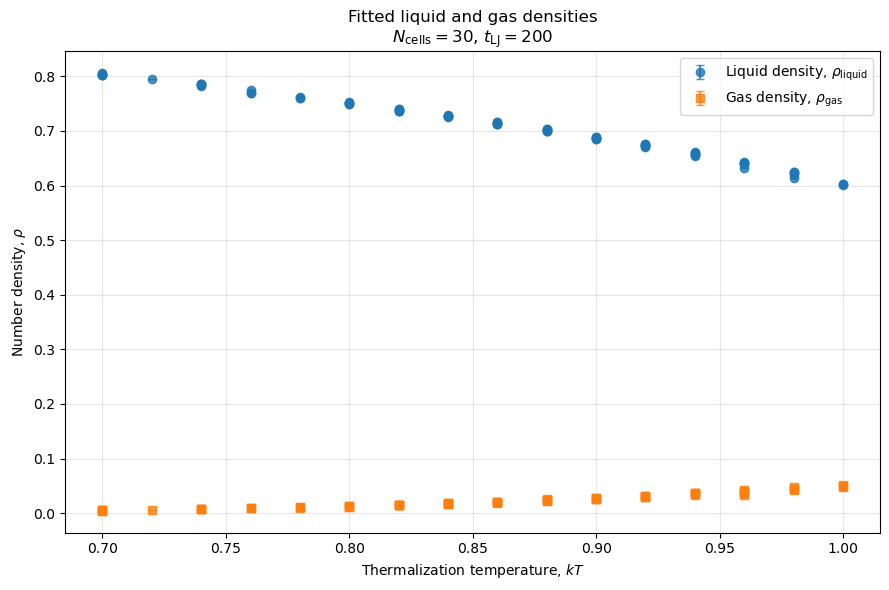

Plotted 79 matching runs.


,Run_ID,Therm_kT,rho_liquid,rho_liquid_unc,rho_gas,rho_gas_unc
0,20260914185855,0.7,0.805684,0.000348,0.005048,0.000104
1,20260914190819,0.7,0.804306,0.000315,0.005004,0.000137
2,20260914191052,0.7,0.803502,0.000309,0.004449,0.00016
3,20260914191240,0.7,0.802753,0.0003,0.004648,0.000174
4,20260914191448,0.7,0.802165,0.000302,0.004933,0.00022
...,...,...,...,...,...,...
74,20260915183740,0.98,0.619647,0.000418,0.044646,0.001254
75,20260915183749,0.98,0.614569,0.000399,0.04167,0.001713
76,20260915184126,1.0,0.603517,0.000493,0.051119,0.000969
77,20260915184318,1.0,0.602611,0.000474,0.048858,0.001142


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from md_Helpers import (
    ProjectPaths,
    SQLiteRunDatabase,
    thermalization_dataframe,
)


# ============================================================
# Select matching thermalization runs
# ============================================================

paths = ProjectPaths()
database = SQLiteRunDatabase(paths.database)


matches = thermalization_dataframe(
    database,
    N_Cells=40,
    This_LJ_Time=200,
    Cumulative_LJ_Time=200,
    Phase_Separation_Status="Separated",
    rho_gas_unc=(None, 0.002),
    Therm_kT=(.3, None),
    Clone_Run_ID=None,
)


# ============================================================
# Prepare fitted phase-density data
# ============================================================

required_columns = [
    "Run_ID",
    "Therm_kT",
    "rho_liquid",
    "rho_liquid_unc",
    "rho_gas",
    "rho_gas_unc",
]

missing_columns = [
    column
    for column in required_columns
    if column not in matches.columns
]

if missing_columns:
    raise KeyError(
        f"Missing required columns: {missing_columns}"
    )

plot_data = matches[required_columns].copy()

for column in [
    "Therm_kT",
    "rho_liquid",
    "rho_liquid_unc",
    "rho_gas",
    "rho_gas_unc",
]:
    plot_data[column] = pd.to_numeric(
        plot_data[column],
        errors="coerce",
    )

plot_data = (
    plot_data
    .dropna(
        subset=[
            "Therm_kT",
            "rho_liquid",
            "rho_gas",
        ]
    )
    .sort_values(["Therm_kT", "Run_ID"])
    .reset_index(drop=True)
)

if plot_data.empty:
    raise ValueError(
        "The matching runs do not contain successful liquid/gas "
        "density fits."
    )


# ============================================================
# Convert to ordinary NumPy arrays
# ============================================================

temperature = plot_data["Therm_kT"].to_numpy(
    dtype=float
)

rho_liquid = plot_data["rho_liquid"].to_numpy(
    dtype=float
)

rho_gas = plot_data["rho_gas"].to_numpy(
    dtype=float
)

rho_liquid_unc = plot_data[
    "rho_liquid_unc"
].to_numpy(
    dtype=float,
    na_value=np.nan,
)

rho_gas_unc = plot_data[
    "rho_gas_unc"
].to_numpy(
    dtype=float,
    na_value=np.nan,
)

# Matplotlib cannot plot missing error magnitudes, so display
# points with missing uncertainties without an error-bar extent.
rho_liquid_unc = np.where(
    np.isfinite(rho_liquid_unc),
    rho_liquid_unc,
    0.0,
)

rho_gas_unc = np.where(
    np.isfinite(rho_gas_unc),
    rho_gas_unc,
    0.0,
)

# ============================================================
# Plot every matching run
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 6),
)

ax.errorbar(
    temperature,
    rho_liquid,
    yerr=rho_liquid_unc,
    fmt="o",
    markersize=6,
    capsize=3,
    color="tab:blue",
    alpha=0.8,
    linestyle="none",
    label=r"Liquid density, $\rho_{\mathrm{liquid}}$",
)

ax.errorbar(
    temperature,
    rho_gas,
    yerr=rho_gas_unc,
    fmt="s",
    markersize=6,
    capsize=3,
    color="tab:orange",
    alpha=0.8,
    linestyle="none",
    label=r"Gas density, $\rho_{\mathrm{gas}}$",
)

ax.set_xlabel(r"Thermalization temperature, $kT$")
ax.set_ylabel(r"Number density, $\rho$")

ax.set_title(
    "Fitted liquid and gas densities\n"
    r"$N_{\mathrm{cells}}=30$, "
    r"$t_{\mathrm{LJ}}=200$"
)

ax.grid(alpha=0.3)
ax.legend()

fig.tight_layout()
plt.show()


# ============================================================
# Display the exact values used in the plot
# ============================================================

print(f"Plotted {len(plot_data)} matching runs.")

display(
    plot_data[
        [
            "Run_ID",
            "Therm_kT",
            "rho_liquid",
            "rho_liquid_unc",
            "rho_gas",
            "rho_gas_unc",
        ]
    ]
)

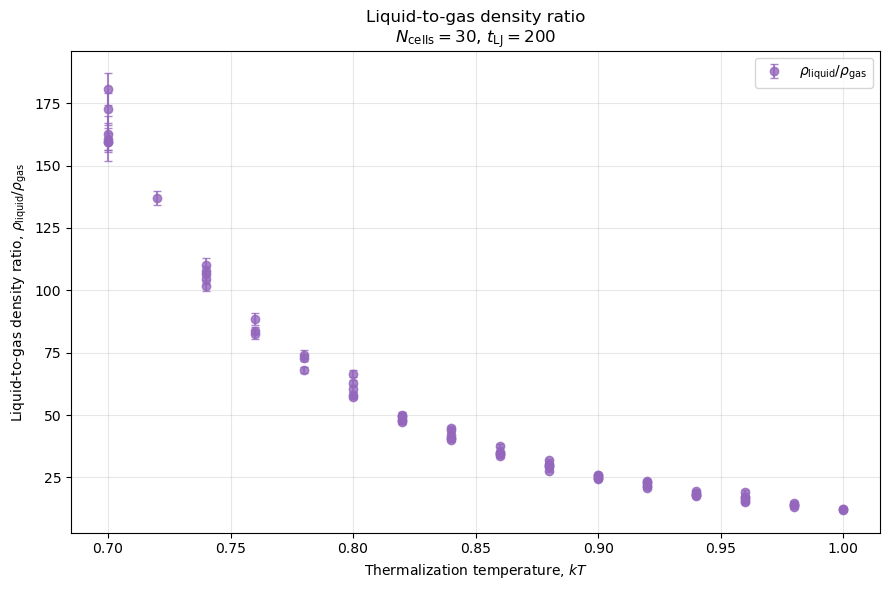

Plotted 79 of 79 runs with complete fit uncertainties.


,Run_ID,Therm_kT,rho_liquid_to_gas,ratio_unc,gas_relative_unc
0,20260914185855,0.7,159.605924,3.304123,0.020697
1,20260914190819,0.7,160.725606,4.398923,0.027366
2,20260914191052,0.7,180.621592,6.485433,0.035904
3,20260914191240,0.7,172.72543,6.479118,0.037509
4,20260914191448,0.7,162.606514,7.265139,0.044678
...,...,...,...,...,...
74,20260915183740,0.98,13.879118,0.390046,0.028095
75,20260915183749,0.98,14.748408,0.606393,0.041111
76,20260915184126,1.0,11.806038,0.224094,0.018964
77,20260915184318,1.0,12.33402,0.288419,0.023371


In [4]:
# Liquid-to-gas density ratio with propagated fit uncertainty.
# Assumes rho_liquid and rho_gas fit errors are uncorrelated.

ratio_data = plot_data[
    [
        "Run_ID",
        "Therm_kT",
        "rho_liquid",
        "rho_liquid_unc",
        "rho_gas",
        "rho_gas_unc",
    ]
].copy()

numeric_columns = [
    "Therm_kT",
    "rho_liquid",
    "rho_liquid_unc",
    "rho_gas",
    "rho_gas_unc",
]

for column in numeric_columns:
    ratio_data[column] = pd.to_numeric(
        ratio_data[column], errors="coerce"
    )

# Do not treat a missing fit uncertainty as zero uncertainty.
ratio_data = ratio_data.dropna(subset=numeric_columns)
ratio_data = ratio_data.loc[
    (ratio_data["rho_liquid"] > 0)
    & (ratio_data["rho_gas"] > 0)
    & (ratio_data["rho_liquid_unc"] >= 0)
    & (ratio_data["rho_gas_unc"] >= 0)
].copy()

if ratio_data.empty:
    raise ValueError(
        "No runs have positive phase densities and both fit uncertainties."
    )

ratio_data["rho_liquid_to_gas"] = (
    ratio_data["rho_liquid"] / ratio_data["rho_gas"]
)

ratio_data["ratio_unc"] = (
    ratio_data["rho_liquid_to_gas"]
    * np.sqrt(
        (
            ratio_data["rho_liquid_unc"]
            / ratio_data["rho_liquid"]
        ) ** 2
        + (
            ratio_data["rho_gas_unc"]
            / ratio_data["rho_gas"]
        ) ** 2
    )
)

ratio_data["gas_relative_unc"] = (
    ratio_data["rho_gas_unc"] / ratio_data["rho_gas"]
)

ratio_data = ratio_data.sort_values(
    ["Therm_kT", "Run_ID"]
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 6))

ax.errorbar(
    ratio_data["Therm_kT"].to_numpy(dtype=float),
    ratio_data["rho_liquid_to_gas"].to_numpy(dtype=float),
    yerr=ratio_data["ratio_unc"].to_numpy(dtype=float),
    fmt="o",
    linestyle="none",
    capsize=3,
    color="tab:purple",
    alpha=0.8,
    label=r"$\rho_{\mathrm{liquid}}/\rho_{\mathrm{gas}}$",
)

ax.set_xlabel(r"Thermalization temperature, $kT$")
ax.set_ylabel(
    r"Liquid-to-gas density ratio, "
    r"$\rho_{\mathrm{liquid}}/\rho_{\mathrm{gas}}$"
)
ax.set_title(
    "Liquid-to-gas density ratio\n"
    r"$N_{\mathrm{cells}}=30$, $t_{\mathrm{LJ}}=200$"
)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

print(
    f"Plotted {len(ratio_data)} of {len(plot_data)} runs "
    "with complete fit uncertainties."
)

if (ratio_data["gas_relative_unc"] > 0.2).any():
    print(
        "Caution: some vapor-density uncertainties exceed 20% "
        "of the fitted vapor density. First-order symmetric ratio "
        "error bars may be a poor approximation for those points."
    )

display(
    ratio_data[
        [
            "Run_ID",
            "Therm_kT",
            "rho_liquid_to_gas",
            "ratio_unc",
            "gas_relative_unc",
        ]
    ]
)

Fitted epsilon/kB: 129.024 ± 0.033 K
Points fitted:     79
Chi-square:        776.09
Degrees of freedom: 78
Reduced chi-square: 9.95


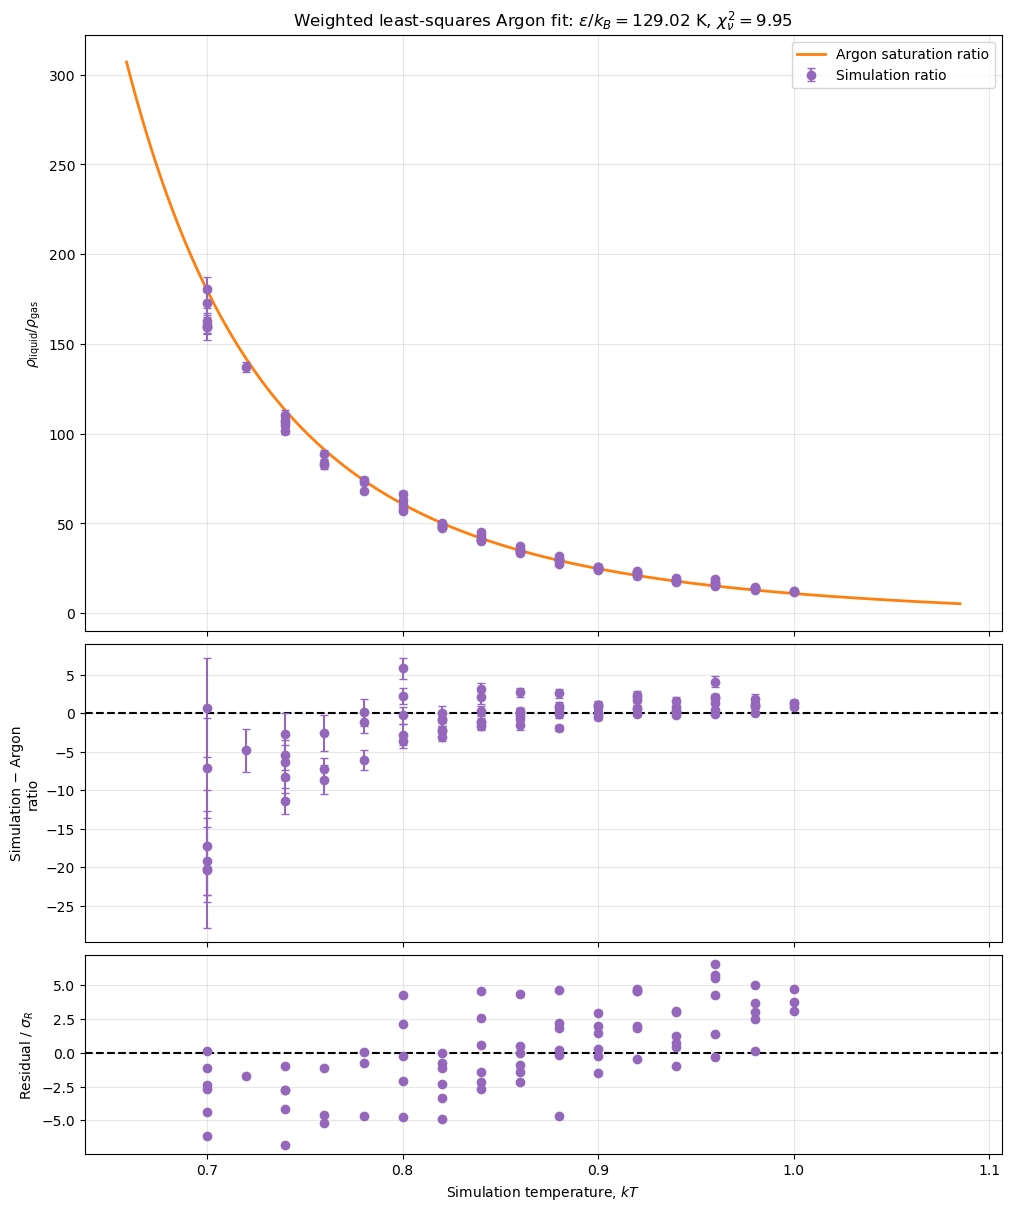

,Run_ID,Therm_kT,rho_liquid_to_gas,ratio_unc,argon_ratio_at_fitted_T,weighted_residual
0,20260914185855,0.7,159.605924,3.304123,179.898364,-6.141551
1,20260914190819,0.7,160.725606,4.398923,179.898364,-4.358512
2,20260914191052,0.7,180.621592,6.485433,179.898364,0.111516
3,20260914191240,0.7,172.72543,6.479118,179.898364,-1.107085
4,20260914191448,0.7,162.606514,7.265139,179.898364,-2.380113
...,...,...,...,...,...,...
74,20260915183740,0.98,13.879118,0.390046,12.897046,2.517840
75,20260915183749,0.98,14.748408,0.606393,12.897046,3.053074
76,20260915184126,1.0,11.806038,0.224094,10.969569,3.732673
77,20260915184318,1.0,12.33402,0.288419,10.969569,4.730802


In [5]:
from pathlib import Path
from scipy.optimize import least_squares
import md_Helpers

from pathlib import Path

argon_path = (
    Path("/home/pnichols/MDsims/Tech Note/Argon Like")
    / "argon_saturation_clean.csv"
)

if not argon_path.exists():
    raise FileNotFoundError(f"Missing Argon table: {argon_path}")

argon = pd.read_csv(argon_path)

argon_T = pd.to_numeric(
    argon["temperature_K"], errors="coerce"
).to_numpy(dtype=float)

argon_ratio = (
    pd.to_numeric(argon["density_liquid_mol_L"], errors="coerce")
    / pd.to_numeric(argon["density_vapor_mol_L"], errors="coerce")
).to_numpy(dtype=float)

valid_argon = (
    np.isfinite(argon_T)
    & np.isfinite(argon_ratio)
    & (argon_ratio > 0)
)

argon_T = argon_T[valid_argon]
argon_ratio = argon_ratio[valid_argon]

order = np.argsort(argon_T)
argon_T = argon_T[order]
argon_ratio = argon_ratio[order]

if len(argon_T) < 2 or np.any(np.diff(argon_T) <= 0):
    raise ValueError("Argon temperatures must be unique and increasing.")

# Use the propagated uncertainties from the previous cell.
fit_data = ratio_data.copy()

for column in [
    "Therm_kT",
    "rho_liquid_to_gas",
    "ratio_unc",
]:
    fit_data[column] = pd.to_numeric(
        fit_data[column], errors="coerce"
    )

fit_data = fit_data.dropna(
    subset=[
        "Therm_kT",
        "rho_liquid_to_gas",
        "ratio_unc",
    ]
)

fit_data = fit_data.loc[
    (fit_data["Therm_kT"] > 0)
    & (fit_data["rho_liquid_to_gas"] > 0)
    & (fit_data["ratio_unc"] > 0)
].copy()

# Fix the set of fitted points before optimization. Do not let points
# enter or leave the objective as the temperature scale changes.
initial_scale_K = 132

fit_data = fit_data.loc[
    (
        initial_scale_K * fit_data["Therm_kT"]
    ).between(argon_T.min(), argon_T.max())
].copy()

if len(fit_data) < 3:
    raise ValueError(
        "Fewer than three simulation points overlap the Argon "
        "temperature range at the initial scale."
    )

x = fit_data["Therm_kT"].to_numpy(dtype=float)
y = fit_data["rho_liquid_to_gas"].to_numpy(dtype=float)
y_unc = fit_data["ratio_unc"].to_numpy(dtype=float)

# Bounds ensure every selected point stays inside the Argon table.
scale_lower = argon_T.min() / x.min()
scale_upper = argon_T.max() / x.max()

if scale_lower >= scale_upper:
    raise ValueError(
        "The selected simulation temperatures cannot all be mapped "
        "inside the Argon table with one temperature scale."
    )

def weighted_residual(parameters):
    scale_K = parameters[0]
    predicted = np.interp(
        scale_K * x,
        argon_T,
        argon_ratio,
    )
    return (y - predicted) / y_unc

fit = least_squares(
    weighted_residual,
    x0=[np.clip(initial_scale_K, scale_lower, scale_upper)],
    bounds=([scale_lower], [scale_upper]),
)

if not fit.success:
    raise RuntimeError(f"Least-squares fit failed: {fit.message}")

scale_K = float(fit.x[0])
predicted = np.interp(scale_K * x, argon_T, argon_ratio)
weighted_resid = (y - predicted) / y_unc

chi2 = float(np.sum(weighted_resid**2))
dof = len(x) - 1
reduced_chi2 = chi2 / dof

# Local 1-sigma uncertainty from the curvature of chi-square.
jacobian = fit.jac[:, 0]
scale_unc_K = (
    1 / np.sqrt(np.sum(jacobian**2))
    if np.sum(jacobian**2) > 0
    else np.nan
)

fit_data["argon_ratio_at_fitted_T"] = predicted
fit_data["weighted_residual"] = weighted_resid

print(f"Fitted epsilon/kB: {scale_K:.3f} ± {scale_unc_K:.3f} K")
print(f"Points fitted:     {len(x)}")
print(f"Chi-square:        {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"Reduced chi-square: {reduced_chi2:.2f}")

if np.isclose(scale_K, scale_lower) or np.isclose(
    scale_K, scale_upper
):
    print(
        "Caution: the optimum is at a temperature-range bound; "
        "the reported symmetric scale uncertainty is unreliable."
    )

difference = y - predicted

fig, (ax_ratio, ax_diff, ax_resid) = plt.subplots(
    3, 1,
    figsize=(10, 12),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1.5, 1]},
    constrained_layout=True,
)

# Original data and fitted Argon curve
ax_ratio.plot(
    argon_T / scale_K,
    argon_ratio,
    color="tab:orange",
    linewidth=2,
    label="Argon saturation ratio",
)
ax_ratio.errorbar(
    x, y, yerr=y_unc,
    fmt="o", linestyle="none", capsize=3,
    color="tab:purple",
    label="Simulation ratio",
)
ax_ratio.set_ylabel(
    r"$\rho_{\mathrm{liquid}}/\rho_{\mathrm{gas}}$"
)
ax_ratio.set_title(
    rf"Weighted least-squares Argon fit: "
    rf"$\epsilon/k_B={scale_K:.2f}$ K, "
    rf"$\chi^2_\nu={reduced_chi2:.2f}$"
)
ax_ratio.grid(alpha=0.3)
ax_ratio.legend()

# Difference in the original ratio units, with original error bars
ax_diff.axhline(0, color="black", linestyle="--")
ax_diff.errorbar(
    x, difference, yerr=y_unc,
    fmt="o", linestyle="none", capsize=3,
    color="tab:purple",
)
ax_diff.set_ylabel("Simulation − Argon\nratio")
ax_diff.grid(alpha=0.3)

# Difference divided by each point's uncertainty
ax_resid.axhline(0, color="black", linestyle="--")
ax_resid.plot(x, weighted_resid, "o", color="tab:purple")
ax_resid.set_xlabel(r"Simulation temperature, $kT$")
ax_resid.set_ylabel(r"Residual / $\sigma_R$")
ax_resid.grid(alpha=0.3)

plt.show()

display(
    fit_data[
        [
            "Run_ID",
            "Therm_kT",
            "rho_liquid_to_gas",
            "ratio_unc",
            "argon_ratio_at_fitted_T",
            "weighted_residual",
        ]
    ]
)